# Question 1

In [111]:
# setup
import sqlite3 as sq3
import pandas as pd
import matplotlib.pyplot as plt

In [112]:
#sqlite3 opioid.db
#sqlite> .mode csv
#sqlite> .import county_pop_arcos.csv population
#sqlite> .import county_annual.csv annual
#sqlite> .import land_area.csv land
#sqlite> .tables
#should show: 
#annual      land        population
#.quit

In [113]:
conn = sq3.connect("opioid.db")

population = pd.read_sql_query("SELECT * FROM population", conn)
annual = pd.read_sql_query("SELECT * FROM annual", conn)
land = pd.read_sql_query("SELECT * FROM land", conn)

In [114]:
annual[
    (annual["BUYER_STATE"] == "AR") &
    (annual["BUYER_COUNTY"] == "MONTGOMERY")
]
annual.loc[
    (annual["BUYER_STATE"] == "AR") &
    (annual["BUYER_COUNTY"] == "MONTGOMERY"),
    "countyfips"
] = "05097"

annual = annual[annual["BUYER_COUNTY"] != "NA"].copy()

In [115]:
land_area = land[
    ["Areaname", "STCOU", "LND110210D"]
].copy()

In [116]:
land_area = land_area.rename(
    columns={"STCOU": "countyfips"}
)
land_area.head()

,Areaname,countyfips,LND110210D
0,UNITED STATES,00000,3531905.43
1,ALABAMA,01000,50645.33
2,"Autauga, AL",01001,594.44
3,"Baldwin, AL",01003,1589.78
4,"Barbour, AL",01005,884.88


In [117]:
county_info = population.merge(
    land_area,
    on="countyfips",
    how="left"
)

county_info.head()

,?,BUYER_COUNTY,BUYER_STATE,countyfips,STATE,COUNTY,county_name,NAME,variable,year,population,Areaname,LND110210D
0,1,AUTAUGA,AL,01001,1,1,Autauga,"Autauga County, Alabama",B01003_001,2006,51328,"Autauga, AL",594.44
1,2,BALDWIN,AL,01003,1,3,Baldwin,"Baldwin County, Alabama",B01003_001,2006,168121,"Baldwin, AL",1589.78
2,3,BARBOUR,AL,01005,1,5,Barbour,"Barbour County, Alabama",B01003_001,2006,27861,"Barbour, AL",884.88
3,4,BIBB,AL,01007,1,7,Bibb,"Bibb County, Alabama",B01003_001,2006,22099,"Bibb, AL",622.58
4,5,BLOUNT,AL,01009,1,9,Blount,"Blount County, Alabama",B01003_001,2006,55485,"Blount, AL",644.78


In [118]:
opioid = annual.merge(
    county_info,
    left_on=["countyfips", "year"],
    right_on=["countyfips", "year"],
    how="left"
)
opioid.head()
opioid.shape

(27741, 18)

In [119]:
opioid["population"] = pd.to_numeric(opioid["population"], errors="coerce")
opioid["LND110210D"] = pd.to_numeric(opioid["LND110210D"], errors="coerce")
opioid["density"] = opioid["population"] / opioid["LND110210D"]

opioid[["population", "LND110210D", "density"]].head()

,population,LND110210D,density
0,25821.0,490.48,52.644348
1,25745.0,490.48,52.489398
2,25699.0,490.48,52.395612
3,25347.0,490.48,51.677948
4,25643.0,490.48,52.281439


# Question 2

In [120]:
opioid["DOSAGE_UNIT"] = pd.to_numeric(opioid["DOSAGE_UNIT"], errors="coerce")
avg_pills_by_year = (
    opioid.groupby("year", as_index=False)["DOSAGE_UNIT"]
    .mean()
)

avg_pills_by_year

,year,DOSAGE_UNIT
0,2006,2.654669e+06
1,2007,2.995906e+06
2,2008,3.254271e+06
3,2009,3.526038e+06
4,2010,3.783656e+06
5,2011,4.035583e+06
6,2012,3.993064e+06
7,2013,3.861752e+06
8,2014,3.768738e+06


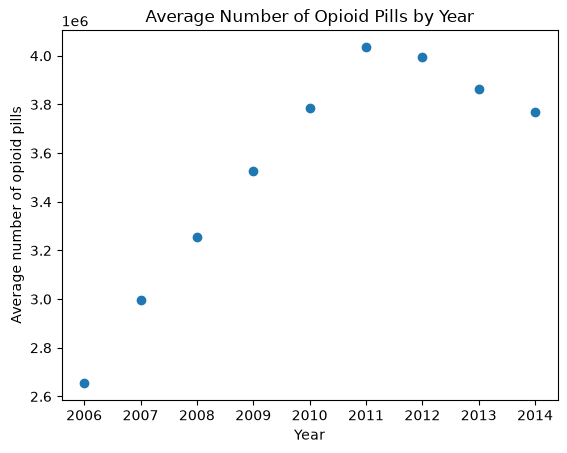

In [121]:
plt.scatter(
    avg_pills_by_year["year"],
    avg_pills_by_year["DOSAGE_UNIT"]
)

plt.xlabel("Year")
plt.ylabel("Average number of opioid pills")
plt.title("Average Number of Opioid Pills by Year")

plt.show()

# Question 4

In [122]:
%pip install rpy2

import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

Note: you may need to restart the kernel to use updated packages.


In [123]:
ro.r('''
library(tidyverse)

setwd("/Users/elisabethlaviolette/Documents/GitHub/Assignment-1")

population <- read_csv("county_pop_arcos.csv", show_col_types = FALSE)
annual <- read_csv("county_annual.csv", show_col_types = FALSE)
land <- read_csv("land_area.csv", show_col_types = FALSE)

annual <- annual %>%
  mutate(
    countyfips = if_else(
      BUYER_STATE == "AR" & BUYER_COUNTY == "MONTGOMERY",
      "05097",
      as.character(countyfips)
    )
  ) %>%
  filter(!is.na(BUYER_COUNTY))

land_area <- land %>%
  select(Areaname, STCOU, LND110210D) %>%
  rename(countyfips = STCOU)

county_info <- population %>%
  left_join(
    land_area,
    by = "countyfips"
  )

opioid <- annual %>%
  left_join(
    county_info,
    by = c("countyfips", "year")
  ) %>%
  mutate(
    population = as.numeric(population),
    LND110210D = as.numeric(LND110210D),
    DOSAGE_UNIT = as.numeric(DOSAGE_UNIT),
    density = population / LND110210D
  )
''')

New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`


In [124]:
r_opioid = ro.globalenv["opioid"]

In [125]:
with localconverter(ro.default_converter + pandas2ri.converter):
    opioid_from_r = ro.conversion.rpy2py(r_opioid)

In [126]:
type(opioid_from_r)
opioid_from_r.shape


(27741, 19)